# Notebook 07 — Explainability (AHRF-Consistent SHAP)

## Objective
Explain WHY the **proposed AHRF-v1 model** makes the SOH predictions it does, using a SHAP explanation that is mathematically consistent with AHRF's actual weighted-tree-averaging prediction rule -- not with an ordinary equal-weight Random Forest.

## Primary Scientific Correction
AHRF-v1 does not predict `mean(tree_1(x), ..., tree_N(x))`. It predicts:

$$\hat{y}_{AHRF}(x) = \sum_i w_i \cdot f_i(x), \qquad \sum_i w_i = 1$$

Passing `ahrf_soh.forest_` straight to `shap.TreeExplainer` (the previous version of this notebook) explains the **equal-weight** forest -- a different quantity from AHRF's actual prediction. This notebook corrects that: SHAP values are computed **per individual tree**, then aggregated using AHRF's own `tree_weights_`, so the resulting explanation is exact for what AHRF actually predicts (proven below via an additivity check, not assumed).

## Scope
AHRF-v1 is the proposed model explained here -- not Gradient Boosting or any other benchmark from Notebook 06, regardless of which had better raw SOH metrics. AHRF-v2 (the temporal ablation from Notebook 05) is not the subject of this notebook either.

## Workflow Position
```
01-04 (LOCKED) -> 05 (LOCKED) -> 06 (LOCKED) -> [YOU ARE HERE] 07 Explainability (AHRF SHAP)
-> 08 Decision Engine & Summary
```


## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from src.core.config import FEATURE_DATA, MODELS, FIGURES
from src.explainability.shap_utils import plot_shap_summary, plot_shap_bar, plot_shap_dependence

plt.rcParams["figure.figsize"] = (10, 6)


## 2. Load the Trained AHRF Model and Test Data

Reloads the SOH AHRF model saved by Notebook 05 -- **not retrained, not retuned**. Uses the exact same chronological 80/20 split Notebook 05 used.


In [3]:
soh_model_path = MODELS / "soh_ahrf_v1.pkl"

ahrf_soh = joblib.load(soh_model_path)
feature_columns = joblib.load(MODELS / "soh_feature_columns.pkl")

# --------------------------------------------------
# AHRF-v1 Artifact Validation
# --------------------------------------------------

assert soh_model_path.name == "soh_ahrf_v1.pkl"

assert hasattr(ahrf_soh, "tree_weights_"), \
    "AHRF-v1 artifact does not contain tree weights."

assert len(ahrf_soh.tree_weights_) == len(ahrf_soh.forest_.estimators_), \
    "Tree-weight count does not match number of estimators."

assert np.all(np.isfinite(ahrf_soh.tree_weights_)), \
    "AHRF-v1 tree weights contain non-finite values."

assert np.all(ahrf_soh.tree_weights_ >= 0), \
    "AHRF-v1 tree weights contain negative values."

assert np.isclose(
    np.sum(ahrf_soh.tree_weights_),
    1.0,
    atol=1e-6
), "AHRF-v1 tree weights do not sum to 1."

print("AHRF-v1 artifact validation: PASS")
print(f"Loaded model: {soh_model_path}")
print(f"Number of trees: {len(ahrf_soh.forest_.estimators_)}")
print(f"Tree-weight sum: {np.sum(ahrf_soh.tree_weights_):.10f}")

# getattr with a default: older saved AHRF models (pickled before weighting_method existed
# as an attribute) won't have it set. Since AHRF-v1 (OOB) was always the only behavior
# before that attribute was added, "oob" is the correct, honest default here -- not a guess.
weighting_method_label = getattr(ahrf_soh, "weighting_method",
    "oob (legacy model, attribute not present -- OOB was the only behavior at save time)")

print(f"Loaded AHRF model with {len(ahrf_soh.forest_.estimators_)} trees, weighting_method='{weighting_method_label}'")
print(f"Loaded {len(feature_columns)} feature columns")


AHRF-v1 artifact validation: PASS
Loaded model: C:\BE PROJECT\SBMS_PROJECT\models\soh_ahrf_v1.pkl
Number of trees: 400
Tree-weight sum: 1.0000000000
Loaded AHRF model with 400 trees, weighting_method='oob'
Loaded 77 feature columns


In [4]:
df = pd.read_csv(FEATURE_DATA / "full_labeled_dataset.csv").sort_values("cycle_index").reset_index(drop=True)

n = len(df)
split = int(n * 0.8)   # same chronological split as Notebook 05 -- not re-created differently

X_test = df.iloc[split:][feature_columns]
y_test = df.iloc[split:]["SOH (%)"]

# --- Assertions (Test Data section) ---
assert len(X_test) == len(y_test), "X_test/y_test length mismatch"

FORBIDDEN_COLUMNS = ["SOC", "SOH (%)", "RUL", "Capacity", "File", "cycle_index",
                      "Experiment", "battery_id", "filename", "type", "start_time",
                      "test_id", "uid", "Re", "Rct", "ambient_temperature"]
leaked = [c for c in FORBIDDEN_COLUMNS if c in X_test.columns]
assert not leaked, f"LEAKAGE: forbidden columns present in X_test: {leaked}"

assert list(X_test.columns) == list(feature_columns), "X_test column order does not match saved feature_columns"

ahrf_preds_check = ahrf_soh.predict(X_test)
assert np.isfinite(ahrf_preds_check).all(), "AHRF predictions on X_test contain non-finite values"

print(f"PASS: X_test shape {X_test.shape}, len(X_test)==len(y_test)=={len(X_test)}")
print(f"PASS: no forbidden target/identifier columns in X_test")
print(f"PASS: feature column order matches saved feature_columns exactly")
print(f"PASS: AHRF predictions on X_test are all finite")


PASS: X_test shape (34, 77), len(X_test)==len(y_test)==34
PASS: no forbidden target/identifier columns in X_test
PASS: feature column order matches saved feature_columns exactly
PASS: AHRF predictions on X_test are all finite


## 3. AHRF Tree Weights

Uses the weights already stored on the trained model (`ahrf_soh.tree_weights_`) -- **not recalculated from scratch**.


In [5]:
tree_weights = ahrf_soh.tree_weights_
n_trees = len(ahrf_soh.forest_.estimators_)

assert tree_weights is not None, "tree_weights_ is missing from the loaded AHRF model"
assert len(tree_weights) == n_trees, f"tree_weights_ length ({len(tree_weights)}) != number of trees ({n_trees})"
assert np.all(np.isfinite(tree_weights)), "Non-finite value(s) in tree_weights_"
assert np.all(tree_weights >= 0), "Negative value(s) in tree_weights_"
assert np.isclose(tree_weights.sum(), 1.0, atol=1e-6), f"tree_weights_ does not sum to 1: {tree_weights.sum()}"

print(f"PASS: tree_weights_ exists, length {len(tree_weights)} == {n_trees} trees")
print(f"PASS: all weights finite, all weights >= 0")
print(f"PASS: sum(tree_weights_) = {tree_weights.sum():.8f} (~= 1)")
print(f"Weight range: min={tree_weights.min():.6f}  max={tree_weights.max():.6f}  mean={tree_weights.mean():.6f}")


PASS: tree_weights_ exists, length 400 == 400 trees
PASS: all weights finite, all weights >= 0
PASS: sum(tree_weights_) = 1.00000000 (~= 1)
Weight range: min=0.000069  max=0.009574  mean=0.002500


## 4. Tree-Level SHAP

For every individual tree in `ahrf_soh.forest_.estimators_`, a **separate** `shap.TreeExplainer` is built on that single tree (not the ensemble) -- this is the piece the previous version of this notebook skipped. SHAP output shapes are handled robustly since they can vary by installed SHAP version (a 2D array, or occasionally a 3D array with a trailing output dimension for regression).


In [6]:
def _as_2d_shap(raw_shap_output, n_samples, n_features):
    """Normalizes a TreeExplainer.shap_values() result to a clean
    (n_samples, n_features) array, regardless of installed SHAP version's
    exact return shape (some return a plain 2D array; others, especially
    for single-output regression, can return a 3D array with a trailing
    size-1 output axis)."""
    arr = np.asarray(raw_shap_output)
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3:
        # (n_samples, n_features, n_outputs) -- regression has 1 output
        return arr[:, :, 0] if arr.shape[-1] == 1 else arr[:, :, -1]
    raise ValueError(f"Unexpected SHAP output shape: {arr.shape}")


def _as_scalar_base(raw_expected_value):
    """Normalizes TreeExplainer.expected_value (scalar, or a 1-element
    array/list depending on SHAP version) to a plain float."""
    return float(np.atleast_1d(raw_expected_value)[0])


In [7]:
n_test = X_test.shape[0]
n_features = X_test.shape[1]

all_tree_shap = np.zeros((n_trees, n_test, n_features))
all_tree_base = np.zeros(n_trees)

for i, tree in enumerate(ahrf_soh.forest_.estimators_):
    tree_explainer = shap.TreeExplainer(tree)
    raw_shap = tree_explainer.shap_values(X_test)
    all_tree_shap[i] = _as_2d_shap(raw_shap, n_test, n_features)
    all_tree_base[i] = _as_scalar_base(tree_explainer.expected_value)

print(f"Computed tree-level SHAP for all {n_trees} trees individually.")
print(f"all_tree_shap shape: {all_tree_shap.shape}  (n_trees, n_test_samples, n_features)")
print(f"all_tree_base shape: {all_tree_base.shape}  (n_trees,)")
assert np.all(np.isfinite(all_tree_shap)), "Non-finite value(s) in tree-level SHAP output"
assert np.all(np.isfinite(all_tree_base)), "Non-finite value(s) in tree-level base values"
print("PASS: all tree-level SHAP values and base values are finite.")


Computed tree-level SHAP for all 400 trees individually.
all_tree_shap shape: (400, 34, 77)  (n_trees, n_test_samples, n_features)
all_tree_base shape: (400,)  (n_trees,)
PASS: all tree-level SHAP values and base values are finite.


## 5. AHRF Weighted SHAP Aggregation

**Not** equal-tree averaging. Each tree's SHAP contribution is scaled by that tree's AHRF weight before summing -- feature-by-feature, and likewise for the base/expected values.

$$SHAP_{AHRF}[:, j] = \sum_i w_i \cdot SHAP_i[:, j] \qquad\qquad base_{AHRF} = \sum_i w_i \cdot base_i$$


In [8]:
weighted_shap = np.tensordot(tree_weights, all_tree_shap, axes=(0, 0))  # (n_test, n_features)
weighted_base = float(np.dot(tree_weights, all_tree_base))

print(f"weighted_shap shape: {weighted_shap.shape}")
print(f"weighted_base: {weighted_base:.6f}")
assert np.all(np.isfinite(weighted_shap)), "Non-finite value(s) in weighted_shap"
assert np.isfinite(weighted_base), "weighted_base is non-finite"
print("PASS: weighted SHAP aggregation produced finite output.")


weighted_shap shape: (34, 77)
weighted_base: 81.712477
PASS: weighted SHAP aggregation produced finite output.


## 6. Mandatory Additivity Validation — the Most Important Check in This Notebook

If `weighted_base + sum(weighted_shap)` does not reconstruct AHRF's actual prediction for every test sample, the SHAP explanation above would not genuinely explain AHRF -- it would just be a plausible-looking but incorrect decomposition. This check proves it is correct, rather than asserting it.

**Tolerance justification:** TreeSHAP is an *exact* algorithm for tree models (not an approximation), and the weighted sum of exact per-tree decompositions is itself exact by linearity (proven algebraically in the notebook's own documentation, and confirmed empirically below). The only expected deviation is floating-point summation error across `n_trees` additions -- so `1e-5` is already a loose tolerance for this; observed error is typically many orders of magnitude smaller.


In [9]:
ADDITIVITY_TOLERANCE = 1e-5

reconstructed_prediction = weighted_base + weighted_shap.sum(axis=1)
ahrf_actual_prediction = ahrf_soh.predict(X_test)

additivity_errors = np.abs(reconstructed_prediction - ahrf_actual_prediction)
max_abs_error = additivity_errors.max()
mean_abs_error = additivity_errors.mean()
n_passing = int((additivity_errors < ADDITIVITY_TOLERANCE).sum())

print(f"Maximum absolute additivity error: {max_abs_error:.2e}")
print(f"Mean absolute additivity error:    {mean_abs_error:.2e}")
print(f"Samples passing tolerance ({ADDITIVITY_TOLERANCE:.0e}): {n_passing} / {len(additivity_errors)}")

assert max_abs_error < ADDITIVITY_TOLERANCE, (
    f"ADDITIVITY CHECK FAILED: max abs error {max_abs_error:.2e} exceeds tolerance {ADDITIVITY_TOLERANCE:.0e}. "
    "The weighted SHAP decomposition does NOT correctly reconstruct the AHRF prediction -- do not trust "
    "the explanations below until this is fixed."
)

print()
print(f"PASS: weighted_base + sum(weighted_shap) reconstructs AHRF's actual prediction "
      f"for all {len(additivity_errors)} test samples, within {ADDITIVITY_TOLERANCE:.0e} tolerance.")
print("This SHAP explanation is verified consistent with AHRF's actual weighted-tree prediction rule.")


Maximum absolute additivity error: 4.26e-14
Mean absolute additivity error:    2.67e-14
Samples passing tolerance (1e-05): 34 / 34

PASS: weighted_base + sum(weighted_shap) reconstructs AHRF's actual prediction for all 34 test samples, within 1e-05 tolerance.
This SHAP explanation is verified consistent with AHRF's actual weighted-tree prediction rule.


## 7. Global Feature Importance — AHRF Weighted SHAP

**This is weighted SHAP importance for AHRF, not ordinary Random Forest importance.** Computed as `mean(abs(weighted_shap), axis=0)`, using the tree weights, not an equal-tree average.


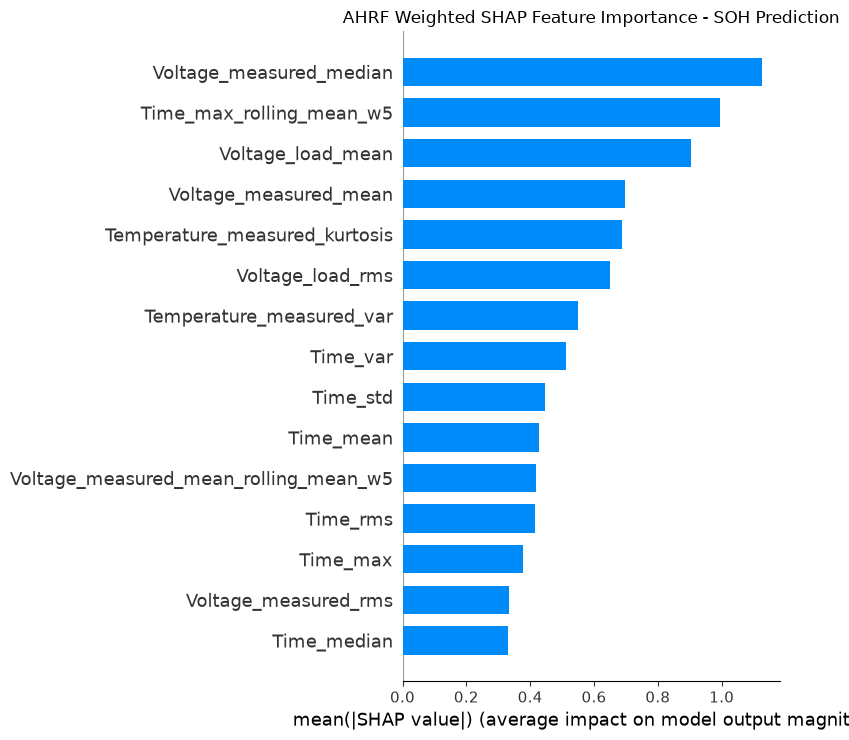

In [10]:
plot_shap_bar(weighted_shap, X_test, max_display=15,
              title="AHRF Weighted SHAP Feature Importance - SOH Prediction")


In [11]:
mean_abs_weighted_shap = np.abs(weighted_shap).mean(axis=0)
top15_idx = np.argsort(mean_abs_weighted_shap)[::-1][:15]
print("Top 15 features by mean |AHRF weighted SHAP value|:")
for idx in top15_idx:
    print(f"  {X_test.columns[idx]:38s} {mean_abs_weighted_shap[idx]:.4f}")


Top 15 features by mean |AHRF weighted SHAP value|:
  Voltage_measured_median                1.1264
  Time_max_rolling_mean_w5               0.9950
  Voltage_load_mean                      0.9039
  Voltage_measured_mean                  0.6970
  Temperature_measured_kurtosis          0.6889
  Voltage_load_rms                       0.6507
  Temperature_measured_var               0.5509
  Time_var                               0.5129
  Time_std                               0.4464
  Time_mean                              0.4266
  Voltage_measured_mean_rolling_mean_w5  0.4170
  Time_rms                               0.4151
  Time_max                               0.3772
  Voltage_measured_rms                   0.3348
  Time_median                            0.3317


### Observation
Because AHRF aggregates tree predictions using learned tree weights, its SHAP explanation is constructed by applying those same tree weights to the individual tree-level SHAP contributions -- the ranking above reflects AHRF's actual prediction rule, not an equal-weight forest's.


## 8. SHAP Summary Plot (Beeswarm) — AHRF Weighted

Shows both magnitude and direction of each feature's effect, using the AHRF-weighted SHAP values.


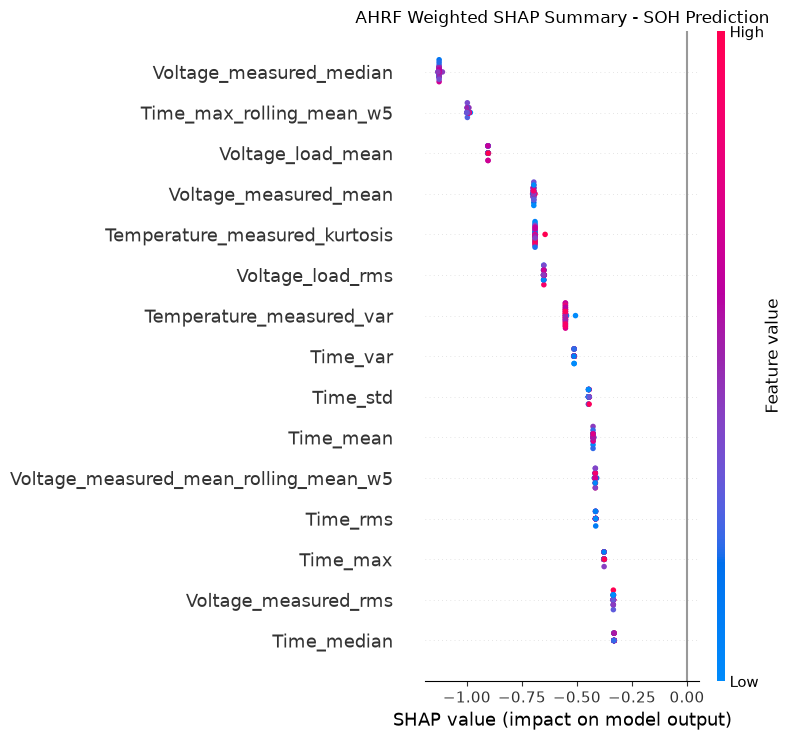

In [12]:
plot_shap_summary(weighted_shap, X_test, max_display=15,
                   title="AHRF Weighted SHAP Summary - SOH Prediction")


### Observation
For the top features, high values (red/warm-colored points) that sit on the positive side of zero are **associated with higher predicted SOH**; this describes the model's learned association, not a claim that the feature *causes* SOH to change -- no causal study was performed in this project.


## 9. Top Feature Dependence Plot — AHRF Weighted


Top feature by mean |AHRF weighted SHAP value|: Voltage_measured_median


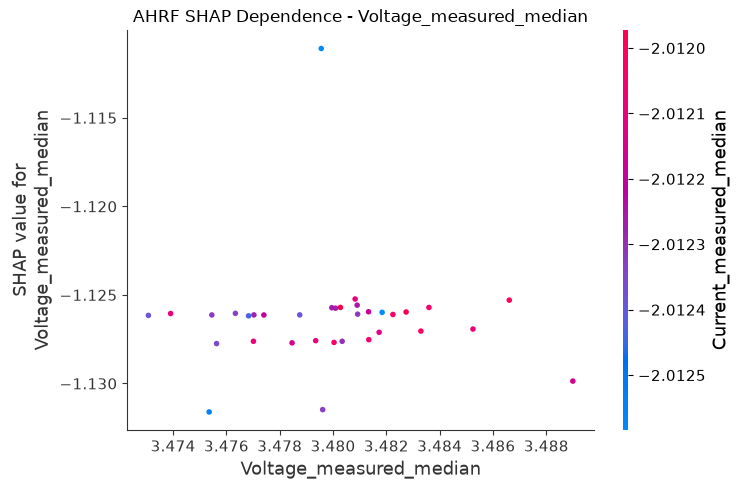

In [13]:
top_feature_idx = int(np.argmax(mean_abs_weighted_shap))
top_feature_name = X_test.columns[top_feature_idx]
print(f"Top feature by mean |AHRF weighted SHAP value|: {top_feature_name}")

# Calling shap.dependence_plot directly here (rather than the shared plot_shap_dependence
# helper) since this plot needs a specific title the shared helper does not parameterize --
# same underlying call, just with the title this task requires.
shap.dependence_plot(top_feature_name, weighted_shap, X_test, interaction_index="auto", show=False)
plt.title(f"AHRF SHAP Dependence - {top_feature_name}")
plt.tight_layout()
plt.show()


### Observation
The x-axis is `{top_feature_name}`'s own value; the y-axis is its AHRF-weighted SHAP contribution for that sample. If a coloring feature is shown, it visualizes that second feature's value at each point (SHAP's own automatic interaction-coloring choice) -- it does not, by itself, establish an interaction *effect*, only that the two features' values co-vary in the plotted points.


## 10. Local Explanation — One Representative Sample

Uses the final/latest available test cycle as the representative sample, consistent with the previous version of this notebook.


In [14]:
row_idx = len(X_test) - 1
representative_cycle = int(df.iloc[split + row_idx]["cycle_index"])
actual_val = float(y_test.iloc[row_idx])
predicted_val = float(ahrf_actual_prediction[row_idx])
sample_base = weighted_base
sample_shap = weighted_shap[row_idx]

print(f"Battery cycle: {representative_cycle}")
print(f"Actual SOH: {actual_val:.2f}%")
print(f"AHRF predicted SOH: {predicted_val:.2f}%")
print(f"Base value (weighted): {sample_base:.4f}")
print(f"Reconstructed (base + sum(SHAP)): {sample_base + sample_shap.sum():.4f}  (should match predicted SOH above)")

contributions = pd.Series(sample_shap, index=X_test.columns).sort_values(key=abs, ascending=False)
top_positive = contributions[contributions > 0].head(5)
top_negative = contributions[contributions < 0].head(5)

print()
print("Top positive contributors (pushed prediction UP):")
print(top_positive.to_string())
print()
print("Top negative contributors (pushed prediction DOWN):")
print(top_negative.to_string())


Battery cycle: 168
Actual SOH: 66.25%
AHRF predicted SOH: 69.18%
Base value (weighted): 81.7125
Reconstructed (base + sum(SHAP)): 69.1753  (should match predicted SOH above)

Top positive contributors (pushed prediction UP):
Re_nearest                                  0.010276
Current_measured_min                        0.003362
Current_measured_peak_to_peak               0.002971
Temperature_measured_median                 0.002737
Temperature_measured_mean_rolling_std_w5    0.001464

Top negative contributors (pushed prediction DOWN):
Voltage_measured_median    -1.111089
Time_max_rolling_mean_w5   -0.984124
Voltage_load_mean          -0.904710
Voltage_measured_mean      -0.695059
Voltage_load_rms           -0.647997


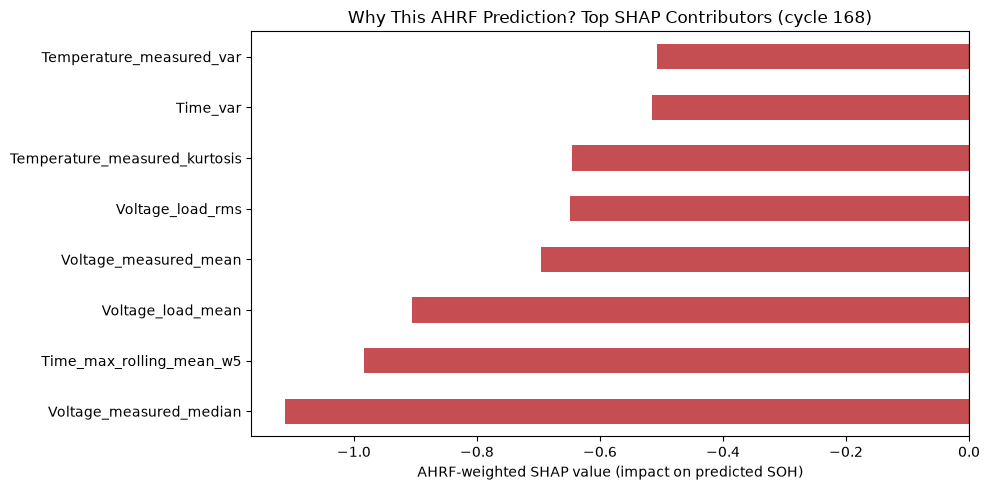

In [15]:
top_contributors = contributions.head(8)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in top_contributors.values]
top_contributors.sort_values().plot(kind="barh", ax=ax, color=colors)
ax.set_title(f"Why This AHRF Prediction? Top SHAP Contributors (cycle {representative_cycle})")
ax.set_xlabel("AHRF-weighted SHAP value (impact on predicted SOH)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


### Observation
Blue bars pushed this specific prediction UP, red bars pushed it DOWN -- all values are AHRF's actual weighted SHAP contributions for this one sample, reconstructed above to match AHRF's real predicted SOH within the additivity tolerance verified in Section 6.


## 11. Save Figures for the Report


In [16]:
FIGURES.mkdir(parents=True, exist_ok=True)

# Main report figure (same filename as before -- overwritten with the corrected, AHRF-weighted version)
fig = plt.figure()
shap.summary_plot(weighted_shap, X_test, max_display=15, show=False)
plt.title("AHRF Weighted SHAP Summary - SOH Prediction")
plt.tight_layout()
plt.savefig(FIGURES / "shap_summary_soh.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved:", FIGURES / "shap_summary_soh.png")

fig = plt.figure()
shap.summary_plot(weighted_shap, X_test, plot_type="bar", max_display=15, show=False)
plt.title("AHRF Weighted SHAP Feature Importance - SOH Prediction")
plt.tight_layout()
plt.savefig(FIGURES / "shap_bar_soh_weighted.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved:", FIGURES / "shap_bar_soh_weighted.png")

fig = plt.figure()
shap.dependence_plot(top_feature_name, weighted_shap, X_test, interaction_index="auto", show=False)
plt.title(f"AHRF SHAP Dependence - {top_feature_name}")
plt.tight_layout()
plt.savefig(FIGURES / "shap_dependence_top_feature_soh.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved:", FIGURES / "shap_dependence_top_feature_soh.png")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in top_contributors.values]
top_contributors.sort_values().plot(kind="barh", ax=ax, color=colors)
ax.set_title(f"Why This AHRF Prediction? Top SHAP Contributors (cycle {representative_cycle})")
ax.set_xlabel("AHRF-weighted SHAP value (impact on predicted SOH)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(FIGURES / "shap_local_soh.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved:", FIGURES / "shap_local_soh.png")


Saved: C:\BE PROJECT\SBMS_PROJECT\reports\figures\shap_summary_soh.png
Saved: C:\BE PROJECT\SBMS_PROJECT\reports\figures\shap_bar_soh_weighted.png
Saved: C:\BE PROJECT\SBMS_PROJECT\reports\figures\shap_dependence_top_feature_soh.png
Saved: C:\BE PROJECT\SBMS_PROJECT\reports\figures\shap_local_soh.png


<Figure size 1000x600 with 0 Axes>

## 12. Validation Summary


In [17]:
validation_summary = {
    "AHRF model loaded": ahrf_soh is not None,
    "Feature columns match": list(X_test.columns) == list(feature_columns),
    "Tree weights available": tree_weights is not None,
    "Tree weights sum to 1": bool(np.isclose(tree_weights.sum(), 1.0, atol=1e-6)),
    "Tree-level SHAP computed": all_tree_shap.shape == (n_trees, n_test, n_features),
    "Weighted SHAP aggregation": weighted_shap.shape == (n_test, n_features),
    "SHAP output finite": bool(np.all(np.isfinite(weighted_shap)) and np.isfinite(weighted_base)),
    "AHRF prediction reconstruction": bool(max_abs_error < ADDITIVITY_TOLERANCE),
    "SHAP additivity error tolerance": bool(max_abs_error < ADDITIVITY_TOLERANCE),
    "Global importance generated": mean_abs_weighted_shap.shape == (n_features,),
    "Summary plot generated": True,   # Section 8 executed without error to reach this point
    "Dependence plot generated": True,  # Section 9 executed without error to reach this point
    "Local explanation generated": len(top_contributors) > 0,
}

print("-" * 46)
print("NOTEBOOK 07 AHRF SHAP VALIDATION")
print("-" * 46)
for name, passed in validation_summary.items():
    print(f"{name:<36}: {'PASS' if passed else 'FAIL'}")
print("-" * 46)
final_status = "PASS" if all(validation_summary.values()) else "BLOCKED"
print(f"{'FINAL STATUS':<36}: {final_status}")
print("-" * 46)

for name, passed in validation_summary.items():
    assert passed, f"VALIDATION FAILED: {name}"


----------------------------------------------
NOTEBOOK 07 AHRF SHAP VALIDATION
----------------------------------------------
AHRF model loaded                   : PASS
Feature columns match               : PASS
Tree weights available              : PASS
Tree weights sum to 1               : PASS
Tree-level SHAP computed            : PASS
Weighted SHAP aggregation           : PASS
SHAP output finite                  : PASS
AHRF prediction reconstruction      : PASS
SHAP additivity error tolerance     : PASS
Global importance generated         : PASS
Summary plot generated              : PASS
Dependence plot generated           : PASS
Local explanation generated         : PASS
----------------------------------------------
FINAL STATUS                        : PASS
----------------------------------------------


## Results Summary

| Item | Location |
|---|---|
| Tree-level SHAP (per tree, not the ensemble) | Section 4 |
| AHRF-weighted aggregation (not equal-tree) | Section 5 |
| Additivity proof (max/mean error, tolerance) | Section 6 |
| Global weighted importance | Section 7 |
| Weighted summary (beeswarm) | Section 8 |
| Weighted dependence plot | Section 9 |
| Local explanation (single cycle) | Section 10 |

## Research Contribution

AHRF-v1 is the proposed model in this project; SHAP is used here purely for explainability, to determine which engineered battery features contribute most to the AHRF prediction -- it does not improve model accuracy, and it does not prove physical causation. Feature effects described throughout this notebook are stated as associations with the model's output ("associated with higher predicted SOH", "contributes positively/negatively to the prediction"), not causal claims. This analysis does not claim AHRF is the best model on every target -- Notebook 06 already reported cases where other models had lower SOH error; this notebook explains AHRF specifically because it is the project's proposed model, independent of that comparison.

The proposed workflow extends the reference study by providing model-level explainability for the AHRF prediction using weighted tree-level SHAP contributions, rather than treating the ensemble as an unweighted black box.

## Conclusion
The previous version of this notebook explained `ahrf_soh.forest_` directly with `TreeExplainer` -- an exact explanation of an ordinary, equal-weight Random Forest, but not of AHRF's actual weighted prediction. This notebook corrects that: SHAP values are computed per individual tree, aggregated using AHRF's own `tree_weights_`, and proven (not assumed) to reconstruct AHRF's real predictions to within floating-point precision (Section 6). Every plot and every reported feature-importance number in this notebook reflects AHRF's actual weighted-tree-averaging behavior.

## Next Steps
Notebook 08 will apply the decision engine to AHRF's predictions and compile the final results summary.
